## Install libraries

In [1]:
pip install shap xgboost

In [2]:
pip install plotly

## Import libraries

In [3]:
import matplotlib.pylab as pl
import numpy as np
import xgboost
from sklearn.model_selection import train_test_split
import shap

# print the JS visualization code to the notebook
shap.initjs()

## Import dataset

In [4]:
X, y = shap.datasets.adult()
X_display, y_display = shap.datasets.adult(display=True)

In [5]:
print(X_display)

        Age          Workclass  Education-Num       Marital Status  \
0      39.0          State-gov           13.0        Never-married   
1      50.0   Self-emp-not-inc           13.0   Married-civ-spouse   
2      38.0            Private            9.0             Divorced   
3      53.0            Private            7.0   Married-civ-spouse   
4      28.0            Private           13.0   Married-civ-spouse   
...     ...                ...            ...                  ...   
32556  27.0            Private           12.0   Married-civ-spouse   
32557  40.0            Private            9.0   Married-civ-spouse   
32558  58.0            Private            9.0              Widowed   
32559  22.0            Private            9.0        Never-married   
32560  52.0       Self-emp-inc            9.0   Married-civ-spouse   

               Occupation    Relationship    Race      Sex  Capital Gain  \
0            Adm-clerical   Not-in-family   White     Male        2174.0   
1      

In [6]:
print(y_display)

[False False False ... False False  True]


## Create test-train split

In [7]:
# create a train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)
d_train = xgboost.DMatrix(X_train, label=y_train)
d_test = xgboost.DMatrix(X_test, label=y_test)

In [8]:
print(X.shape)

(32561, 12)


In [9]:
print(X_train)

        Age  Workclass  Education-Num  Marital Status  Occupation  \
12011  51.0          4           10.0               0           6   
23599  51.0          1           14.0               6          12   
23603  21.0          4           11.0               4           3   
6163   25.0          4           10.0               4          12   
14883  48.0          4           13.0               0           1   
...     ...        ...            ...             ...         ...   
5699   23.0          4            9.0               4          12   
10742  37.0          4            9.0               2           7   
16921  27.0          6            5.0               2           3   
25796  46.0          4           16.0               2          10   
28847  55.0          4           10.0               0          13   

       Relationship  Race  Sex  Capital Gain  Capital Loss  Hours per week  \
12011             0     4    0           0.0           0.0            40.0   
23599          

In [10]:
print(X_train.shape)

(26048, 12)


## Define parameters for xgboost

In [11]:
params = {
    "eta": 0.01,
    "objective": "binary:logistic",
    "subsample": 0.5,
    "base_score": np.mean(y_train),
    "eval_metric": "logloss",
}
model = xgboost.train(
    params,
    d_train,
    5000,
    evals=[(d_test, "test")],
    verbose_eval=100,
    early_stopping_rounds=20,
)

[0]	test-logloss:0.54666
[100]	test-logloss:0.36390
[200]	test-logloss:0.31754
[300]	test-logloss:0.30058
[400]	test-logloss:0.29155
[500]	test-logloss:0.28652
[600]	test-logloss:0.28343
[700]	test-logloss:0.28173
[800]	test-logloss:0.28058
[900]	test-logloss:0.27976
[1000]	test-logloss:0.27924
[1100]	test-logloss:0.27893
[1200]	test-logloss:0.27878
[1208]	test-logloss:0.27876


## Print accuracy

In [12]:
from sklearn.metrics import accuracy_score

# Make predictions
y_pred_prob = model.predict(d_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 87.53%


## SHAP explainer

In [13]:
# This takes 5-6 minutes since we are explaining over 30
#thousand samples in a model with over a thousand trees
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

## SHAP force plot
A SHAP force plot explains why a machine-learning model made one particular prediction

In [14]:
import plotly.io as pio

# Set the default renderer for Plotly to 'colab'
pio.renderers.default = 'colab'

# print the JS visualization code to the notebook
shap.initjs()  # Ensure this line is uncommented

shap.force_plot(explainer.expected_value, shap_values[50, :], X_display.iloc[50, :])


In [15]:
# Index of the sample you are interested in
sample_index = 49

# Get feature names
feature_names = X_display.columns

# Get SHAP values for that sample
shap_values_sample = shap_values[sample_index]

# Get the actual feature values for that sample
feature_values = X_display.iloc[sample_index]

# Print SHAP value for each feature
for name, value, shap_val in zip(feature_names, feature_values, shap_values_sample):
    if isinstance(value, (int, float)):  # If it's a number, format it
        val_str = f"{value:10.4f}"
    else:  # Otherwise just print the string
        val_str = f"{str(value):>10}"

    print(f"Feature: {name:20s} | Value: {val_str} | SHAP Value: {shap_val:+.4f}")


Feature: Age                  | Value:       29.0 | SHAP Value: -0.2337
Feature: Workclass            | Value:    Private | SHAP Value: +0.0045
Feature: Education-Num        | Value:       11.0 | SHAP Value: -0.0135
Feature: Marital Status       | Value:  Never-married | SHAP Value: -0.2437
Feature: Occupation           | Value:  Prof-specialty | SHAP Value: +0.3160
Feature: Relationship         | Value:  Not-in-family | SHAP Value: -1.0807
Feature: Race                 | Value:      White | SHAP Value: +0.0218
Feature: Sex                  | Value:       Male | SHAP Value: +0.1408
Feature: Capital Gain         | Value:        0.0 | SHAP Value: -0.1918
Feature: Capital Loss         | Value:        0.0 | SHAP Value: -0.0561
Feature: Hours per week       | Value:       43.0 | SHAP Value: +0.3015
Feature: Country              | Value:  United-States | SHAP Value: +0.0135


In [16]:
# Set the default renderer for Plotly to 'colab'
pio.renderers.default = 'colab'

# print the JS visualization code to the notebook
shap.initjs()  # Ensure this line is uncommented

shap.force_plot(
    explainer.expected_value, shap_values[:1000, :], X_display.iloc[:1000, :]
)

## SHAP summary plot
The purpose of shap.summary_plot(shap_values, X_display, plot_type="bar") is to provide a global explanation of your model by showing which features are most important overall across the dataset.

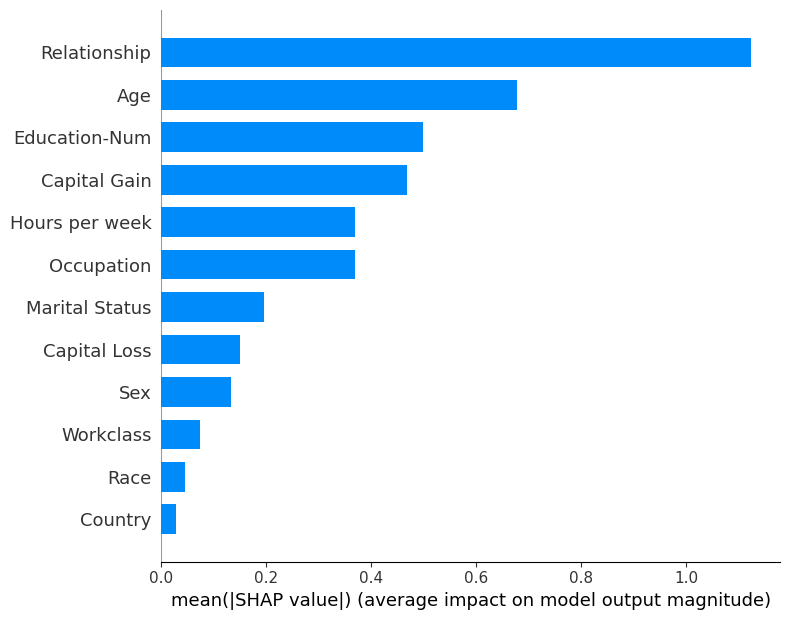

In [17]:
shap.summary_plot(shap_values, X_display, plot_type="bar")

## SHAP dependence plot
A SHAP dependence plot shows how the value of one feature affects the model prediction across many observations.

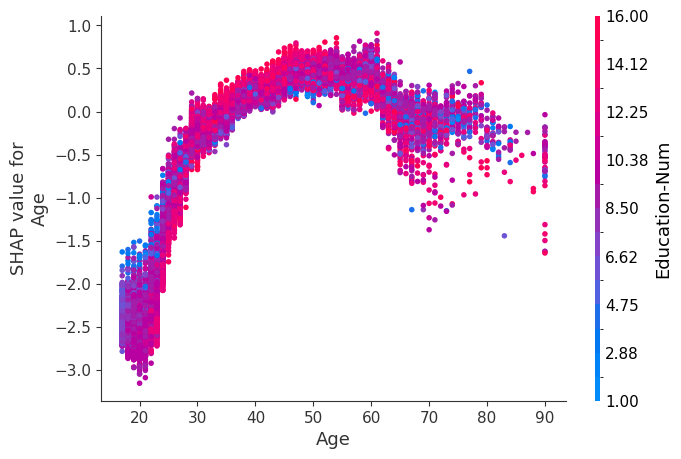

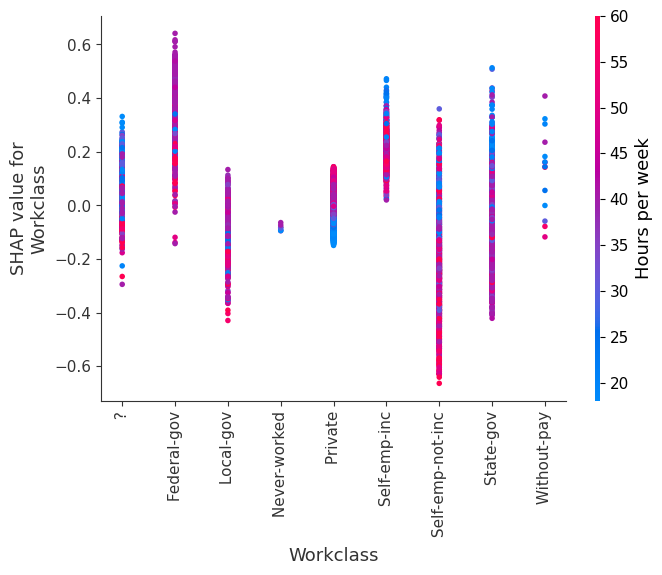

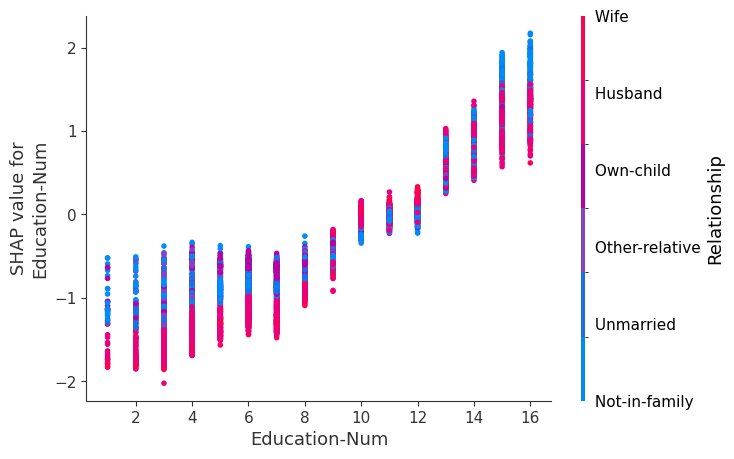

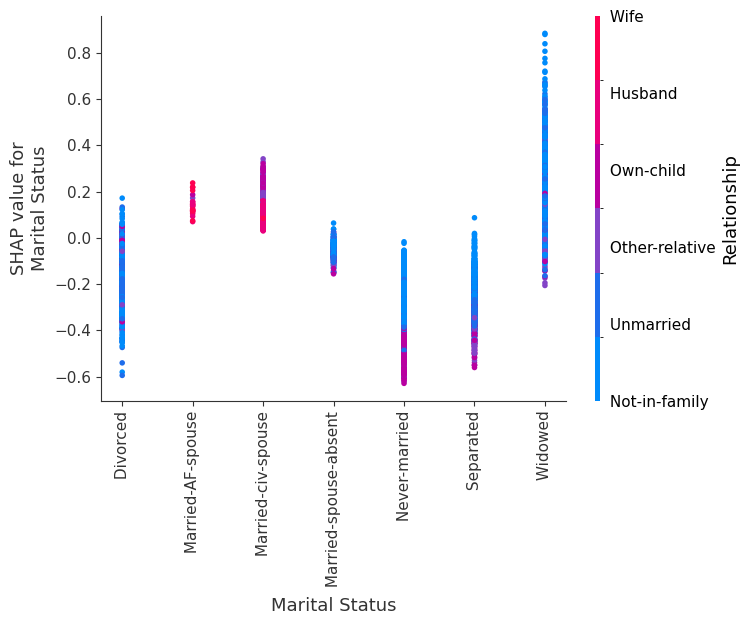

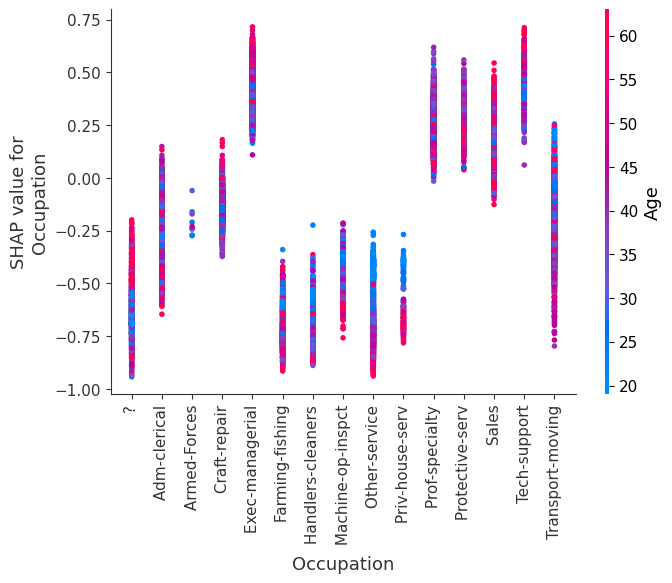

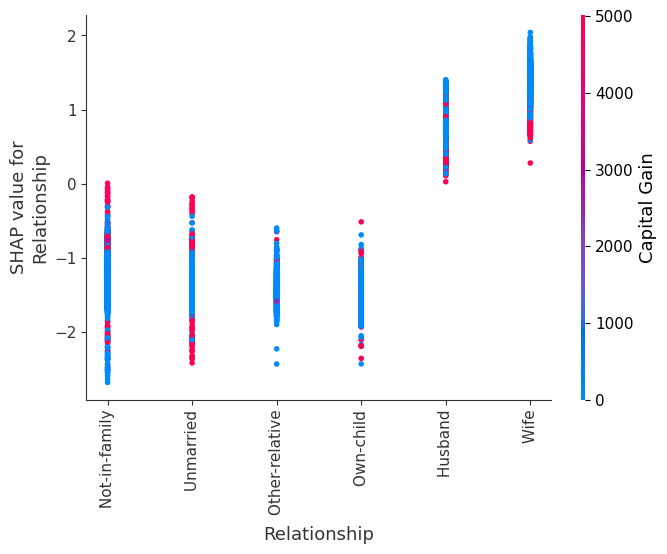

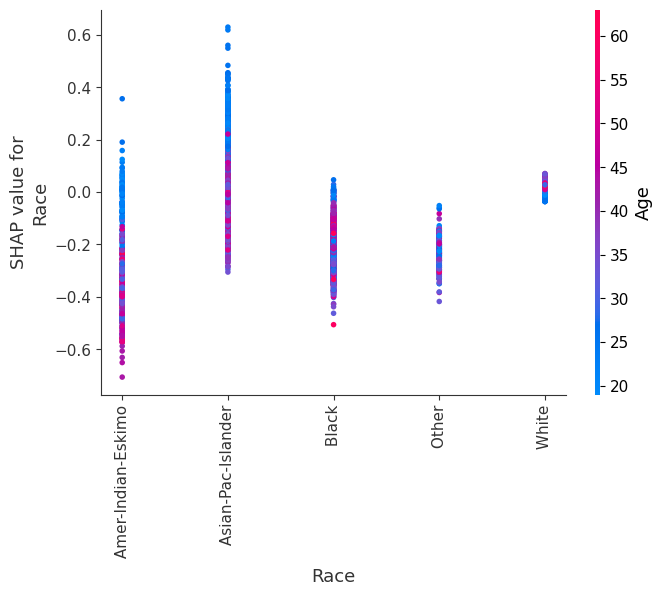

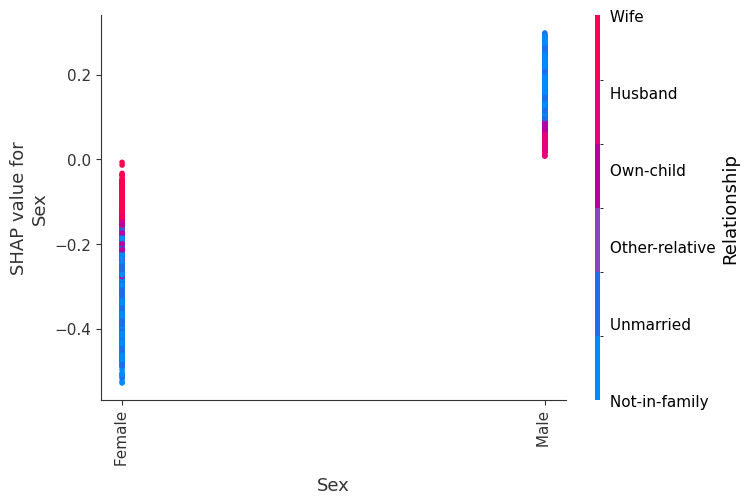

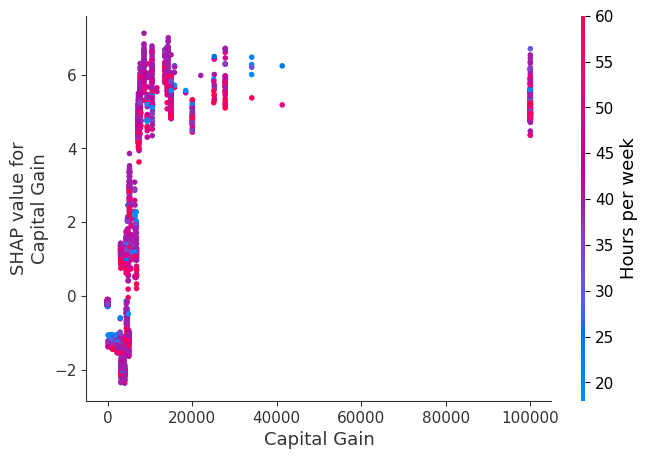

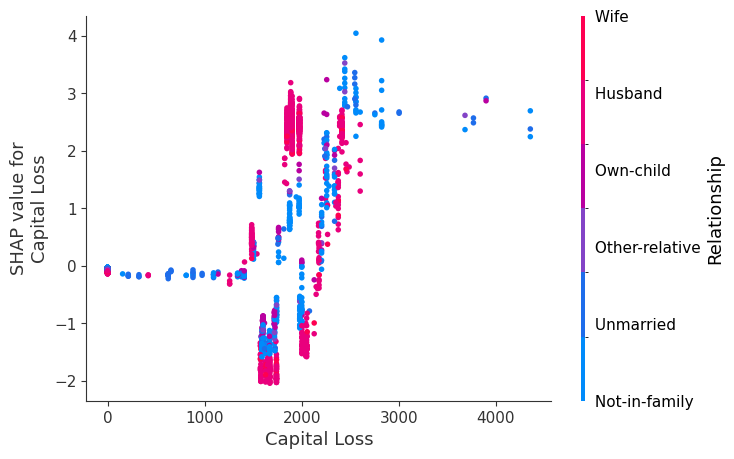

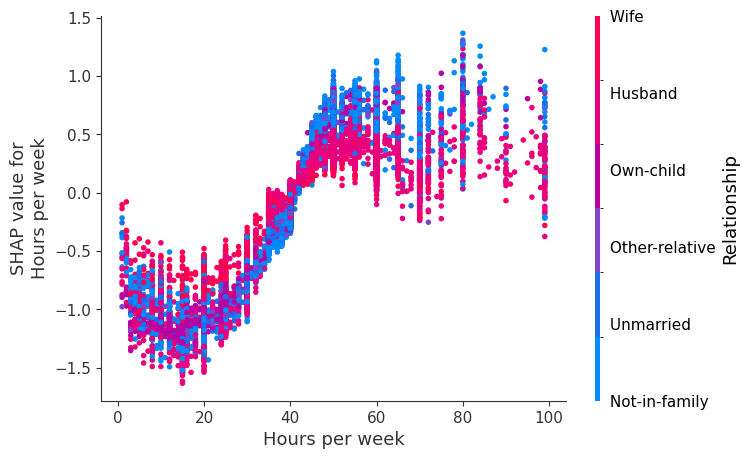

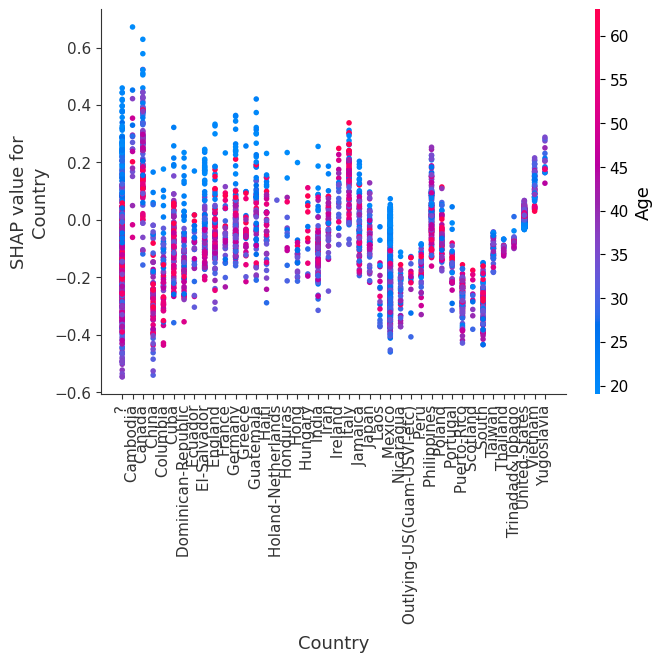

In [18]:
for name in X_train.columns:
    shap.dependence_plot(name, shap_values, X, display_features=X_display)

SHAP beeswarm plot, which is one of the most useful plots for getting a global overview of a machine-learning model.

It answers two questions at the same time:

Which features are most important overall?
For each feature, do its values push predictions higher or lower?

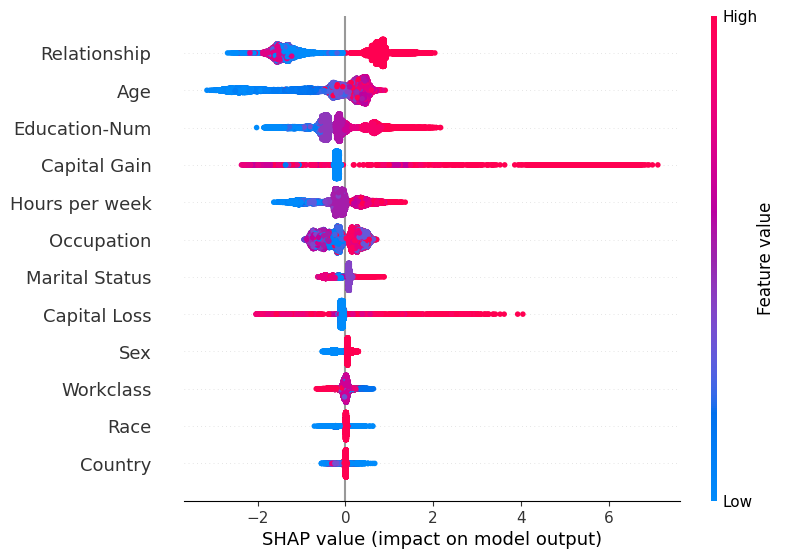

In [19]:
shap_exp = explainer(X)

shap.plots.beeswarm(
    shap_exp,
    max_display=15
)

A SHAP waterfall plot explains why the model made a particular prediction for one observation.

The easiest way to understand it is:

Start with the base value → add/subtract each feature's SHAP contribution → arrive at the final prediction \(f(x)\).

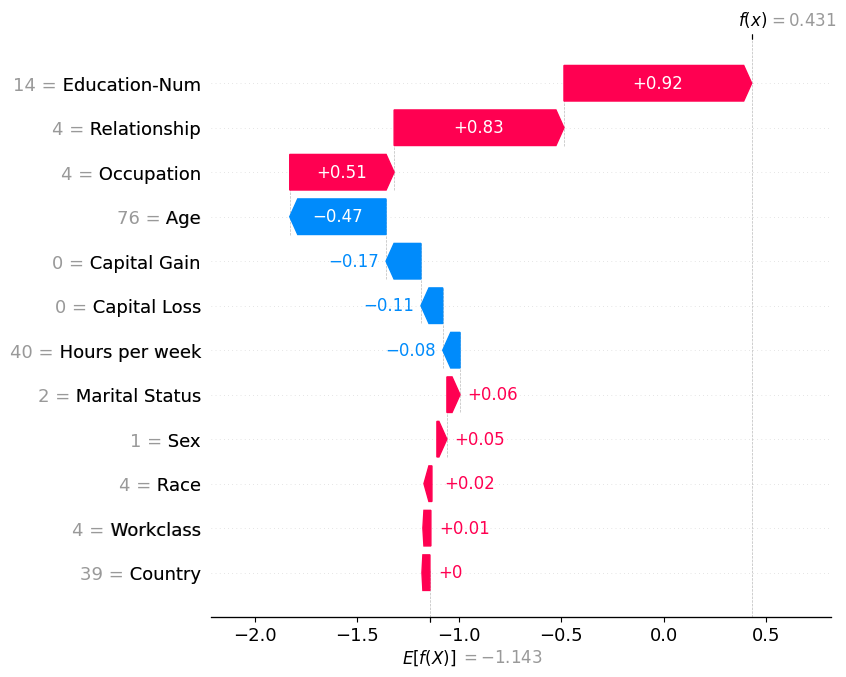

In [20]:
# 4. Waterfall plot
shap.plots.waterfall(shap_exp[100], max_display=15)

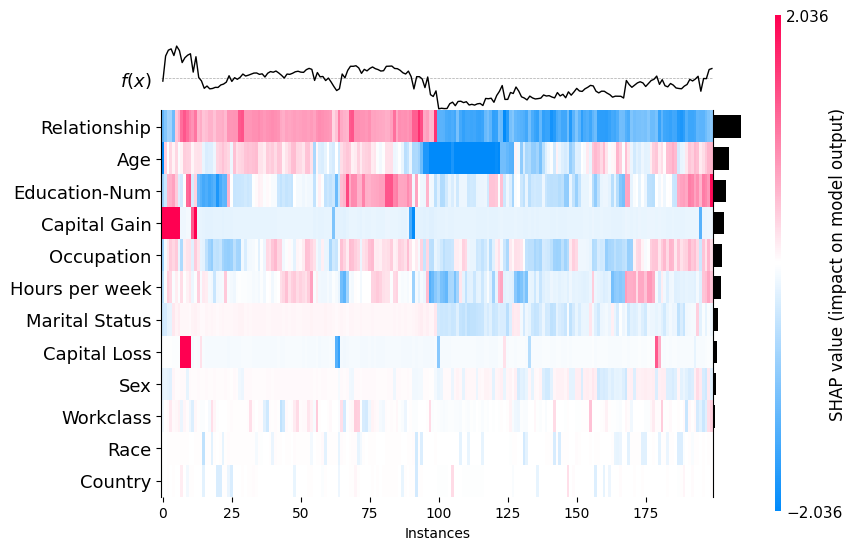

<Axes: xlabel='Instances'>

In [21]:
# 3. Heatmap
shap.plots.heatmap(shap_exp[:200], max_display=15)

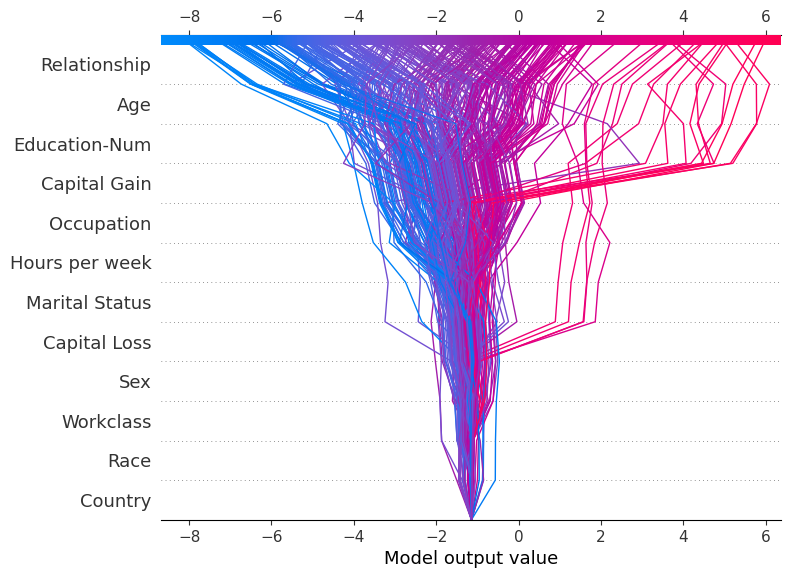

In [22]:
import shap
import matplotlib.pyplot as plt

# Create a smaller sample for a clear plot
X_sample = X.iloc[:300]
shap_sample = shap_values[:300]

shap.decision_plot(
    explainer.expected_value,
    shap_sample,
    X_sample
)



# Explainable AI Using SHAP

### Dataset

Use the **Breast Cancer Wisconsin Diagnostic Dataset** available through `scikit-learn` to build a machine learning model for classifying breast tumours as **malignant or benign** based on their measured characteristics.

### Objective

In this experiment, apply **SHAP (SHapley Additive exPlanations)** as an Explainable AI (XAI) technique to understand how individual features contribute to the predictions made by the trained machine learning model.

The following SHAP visualizations should be used:

* **SHAP Bar Plot** – to identify the globally most important features.
* **SHAP Summary/Beeswarm Plot** – to understand the direction, magnitude, and distribution of feature effects.
* **SHAP Waterfall Plot** – to explain the contribution of features for an individual prediction.
* **SHAP Dependence Plot** – to understand how a feature affects model predictions across different feature values.
* **SHAP Force Plot** – to visualize how features push an individual prediction toward malignant or benign.

---

### Task 1: Load and Prepare the Dataset

* Load the Breast Cancer Wisconsin Diagnostic dataset using `sklearn.datasets`.
* Display the first few records.
* Check the dataset dimensions, data types, and missing values.
* Display the feature names.
* Display the target classes.
* Display descriptive statistics of the input features.
* Separate the input features (`X`) and target variable (`y`).
* Split the data into training and testing sets.

**Comment:**

Explain the structure of the dataset, the target variable, and the purpose of separating the data into training and testing sets.

---

### Task 2: Train a Machine Learning Model

* Select an appropriate machine learning algorithm for classifying breast tumours.
* Train the model using the training dataset.
* Generate predictions for the test dataset.
* Generate prediction probabilities.
* Evaluate the model using suitable performance metrics.
* Report the model performance on the test dataset.

Use a classification model such as **Random Forest Classifier**.

**Comment:**

Explain why the selected machine learning algorithm is appropriate for this dataset and discuss the obtained model performance.

---

### Task 3: Create a SHAP Explainer

* Import the SHAP library.
* Create an appropriate SHAP explainer for the trained machine learning model.
* Calculate the SHAP values for the test dataset.
* Examine the shape of the generated SHAP values.

**Comment:**

Explain:

1. What SHAP stands for.
2. What a SHAP value represents.
3. What a positive SHAP value indicates.
4. What a negative SHAP value indicates.
5. What a SHAP value close to zero means.
6. Why SHAP can be used to explain machine learning predictions.

---

### Task 4: SHAP Feature Importance – Bar Plot

Generate a **SHAP bar plot** showing the global importance of the input features.

* Calculate the mean absolute SHAP value for each feature.
* Rank the features according to their SHAP importance.
* Display the most important features using a bar chart.

**Comment:**

Identify the **top five most important features** and explain how the SHAP bar plot helps in understanding the **global behaviour** of the trained model.

---

### Task 5: SHAP Summary / Beeswarm Plot

Generate a **SHAP summary (beeswarm) plot** for the input features.

Use the plot to investigate:

* Feature importance
* SHAP value magnitude
* Positive and negative feature effects
* High and low feature values
* Distribution of SHAP values

**Comment:**

For the three most important features, explain:

1. How high feature values affect the prediction.
2. How low feature values affect the prediction.
3. Whether the feature generally pushes the prediction toward malignant or benign.
4. Whether the relationship appears linear or nonlinear.

---

### Task 6: SHAP Waterfall Plot

Select at least **one individual tumour sample** from the test dataset.

Generate a **SHAP waterfall plot** to explain its prediction.

Display:

* The base/expected value.
* Individual feature contributions.
* Features that push the prediction toward malignant.
* Features that push the prediction toward benign.
* The final model prediction.

**Comment:**

Explain how each important feature contributes to the prediction of the selected tumour sample.

---

### Task 7: SHAP Force Plot

Generate a **SHAP force plot** for the same individual sample used in Task 6.

**Comment:**

Explain:

1. Which features push the prediction toward malignant?
2. Which features push the prediction toward benign?
3. Which feature has the largest contribution?
4. How does the force plot represent the movement from the base value to the final prediction?

Compare the force plot with the waterfall plot.

---

### Task 8: SHAP Dependence Plot

Generate SHAP dependence plots for three important features identified from the SHAP analysis.

For example:

* `mean radius`
* `mean perimeter`
* `mean concavity`

**Comment:**

For each feature, explain:

1. How the feature value affects the SHAP value.
2. Whether increasing the feature increases or decreases the prediction.
3. Whether the relationship is linear or nonlinear.
4. Whether the effect changes at different feature values.
5. Whether any possible feature interaction can be observed.

---

### Task 9: Compare SHAP Explanations for Different Samples

Select at least **three different tumour samples** from the test dataset.

Generate SHAP explanations for each sample.

Compare their predictions and feature contributions.

**Comment:**

Explain:

1. Why can the same feature have different SHAP values for different samples?
2. Which features are consistently important?
3. Which features show different effects across samples?
4. How does this demonstrate the difference between **global and local explanations**?

---

### Task 10: Compare SHAP with Model Feature Importance

Calculate the built-in feature importance of the Random Forest model.

Compare it with the SHAP feature importance obtained in Task 4.

**Comment:**

Discuss:

1. Are the top-ranked features the same?
2. If there are differences, why might they occur?
3. What additional information does SHAP provide?
4. Why is feature importance alone insufficient for understanding individual predictions?

---

### Task 11: Compare Different SHAP Plots

Compare the following SHAP visualizations:

| SHAP Plot | Main Purpose |
|---|---|
| SHAP Bar Plot | Global feature importance |
| SHAP Beeswarm Plot | Feature importance and direction of effects |
| SHAP Waterfall Plot | Explanation of one individual prediction |
| SHAP Force Plot | Individual feature contributions |
| SHAP Dependence Plot | Relationship between feature values and SHAP values |

**Comment:**

Explain why different SHAP plots are required to obtain a complete understanding of the machine learning model.

---

### Task 12: Global vs Local Explainability

Using the SHAP plots generated in the previous tasks, explain the difference between:

**Global Explanation**

> How does the model generally classify breast tumour samples?

**Local Explanation**

> Why did the model classify this particular tumour sample as malignant or benign?

**Comment:**

Use examples from the SHAP bar/beeswarm plots and waterfall/force plots to support your explanation.

---

### Task 13: Analyse Feature Interactions

Use SHAP dependence analysis to investigate whether two important features interact with each other.

**Comment:**

Discuss:

1. Which two features appear to interact?
2. How does one feature influence the effect of another feature?
3. Why are feature interactions important for understanding model behaviour?
4. Can the effect of a feature change depending on the value of another feature?

---

### Task 14: SHAP-Based Model Analysis

Based on all the SHAP visualizations, identify:

* The five most important features.
* The feature that has the strongest positive contribution toward the predicted class.
* The feature that has the strongest negative contribution.
* Features with nonlinear effects.
* Features that show possible interactions.
* Features that consistently influence individual predictions.

**Comment:**

Explain how the SHAP analysis provides a deeper understanding of the model than simply looking at classification accuracy.

---

### Task 15: Explain a Misclassified Sample

Identify at least **one incorrectly classified sample** from the test dataset.

Generate a SHAP waterfall plot for the misclassified sample.

**Comment:**

Explain:

1. What was the actual class?
2. What class did the model predict?
3. Which features contributed most strongly to the incorrect prediction?
4. Were there features pushing the prediction toward the correct class?
5. What does the SHAP explanation reveal about the model's error?

---

### Task 16: Explain a Correctly Classified Sample

Select one correctly classified sample from the test dataset.

Generate a SHAP waterfall plot.

Compare this explanation with the misclassified sample from Task 15.

**Comment:**

Discuss how the feature contributions differ between the correctly classified and incorrectly classified samples.

---

### Final Observation

Write a short conclusion explaining how **SHAP provides both global and local explanations** of a trained machine learning model for breast cancer classification.

Your conclusion should discuss:

* Overall feature importance.
* Direction of feature effects.
* Individual feature contributions.
* Differences between individual tumour samples.
* Feature interactions.
* Correct and incorrect predictions.
* Global versus local explanations.
* The usefulness and limitations of SHAP for interpreting machine learning models.
* Why human/domain-expert validation is important when interpreting XAI results in healthcare.

In [23]:
# Install SHAP
!pip install -q shap

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [24]:
# Load Breast Cancer Wisconsin Diagnostic Dataset
data = load_breast_cancer()

# Create DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [25]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [26]:
print("Number of rows:", X.shape[0])
print("Number of features:", X.shape[1])
print("Dataset dimensions:", X.shape)

Number of rows: 569
Number of features: 30
Dataset dimensions: (569, 30)


In [27]:
print(X.dtypes)

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

In [28]:
print("Missing values in each feature:")
print(X.isnull().sum())

print("\nTotal missing values:", X.isnull().sum().sum())

Missing values in each feature:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

Total missing values: 0


In [29]:
print("Feature Names:\n")

for i, feature in enumerate(data.feature_names, start=1):
    print(i, feature)

Feature Names:

1 mean radius
2 mean texture
3 mean perimeter
4 mean area
5 mean smoothness
6 mean compactness
7 mean concavity
8 mean concave points
9 mean symmetry
10 mean fractal dimension
11 radius error
12 texture error
13 perimeter error
14 area error
15 smoothness error
16 compactness error
17 concavity error
18 concave points error
19 symmetry error
20 fractal dimension error
21 worst radius
22 worst texture
23 worst perimeter
24 worst area
25 worst smoothness
26 worst compactness
27 worst concavity
28 worst concave points
29 worst symmetry
30 worst fractal dimension


In [30]:
print("Target names:", data.target_names)

print("\nTarget encoding:")
for i, name in enumerate(data.target_names):
    print(i, "=", name)

Target names: ['malignant' 'benign']

Target encoding:
0 = malignant
1 = benign


target
1    357
0    212
Name: count, dtype: int64


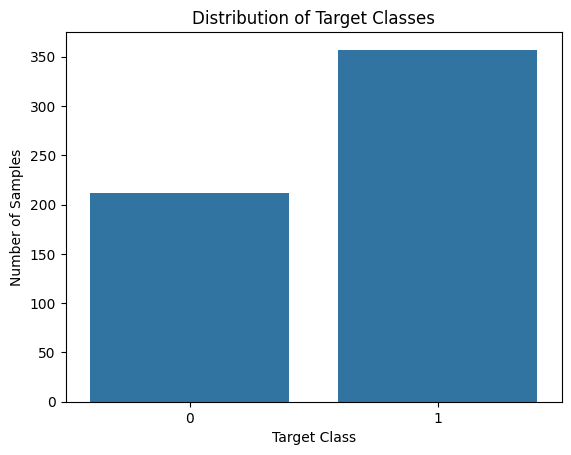

In [31]:
print(y.value_counts())

sns.countplot(x=y)
plt.xlabel("Target Class")
plt.ylabel("Number of Samples")
plt.title("Distribution of Target Classes")
plt.show()

In [32]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


The Breast Cancer Wisconsin Diagnostic dataset contains 569 tumour samples and 30 numerical features describing characteristics of cell nuclei obtained from digitized breast mass images. The target variable contains two classes: malignant and benign. The input features are separated from the target variable so that the machine learning model can learn the relationship between tumour characteristics and the corresponding class. The dataset is divided into training and testing sets to evaluate the model on previously unseen data. The training data is used to learn the model, while the testing data is used to measure its generalization performance.

In [34]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=None,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [35]:
y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(X_test)

print("Predictions:")
print(y_pred[:10])

print("\nPrediction probabilities:")
print(y_prob[:10])

Predictions:
[0 1 0 0 0 1 1 0 0 0]

Prediction probabilities:
[[1.    0.   ]
 [0.    1.   ]
 [0.91  0.09 ]
 [0.665 0.335]
 [0.995 0.005]
 [0.035 0.965]
 [0.02  0.98 ]
 [1.    0.   ]
 [1.    0.   ]
 [1.    0.   ]]


In [36]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob[:, 1])

print("Model Performance")
print("-------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Model Performance
-------------------------
Accuracy  : 0.9474
Precision : 0.9583
Recall    : 0.9583
F1 Score  : 0.9583
ROC-AUC   : 0.9937


In [37]:
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



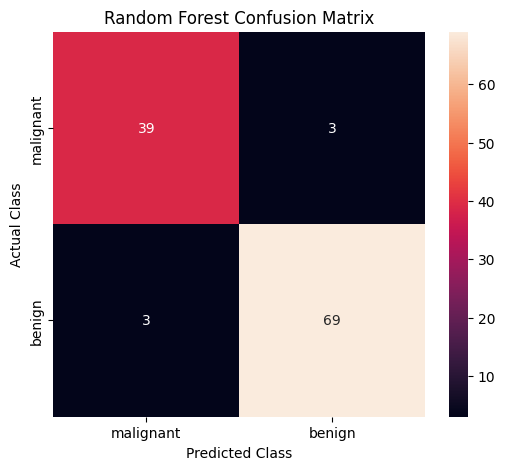

In [38]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [39]:
explainer = shap.TreeExplainer(rf_model)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [40]:
shap_values = explainer(X_test)

print("SHAP values calculated.")
print("SHAP values shape:", shap_values.values.shape)

SHAP values calculated.
SHAP values shape: (114, 30, 2)


In [41]:
# SHAP values corresponding to malignant class
shap_malignant = shap_values.values[:, :, 0]

print("Malignant SHAP matrix shape:", shap_malignant.shape)

Malignant SHAP matrix shape: (114, 30)


In [42]:
print("Expected values:")
print(explainer.expected_value)

Expected values:
[0.50128364 0.49871636]


In [43]:
mean_abs_shap = np.abs(shap_malignant).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean Absolute SHAP": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    by="Mean Absolute SHAP",
    ascending=False
)

shap_importance.head(10)

,Feature,Mean Absolute SHAP
22,worst perimeter,0.072819
23,worst area,0.070043
27,worst concave points,0.051765
7,mean concave points,0.047613
20,worst radius,0.045062
26,worst concavity,0.031471
6,mean concavity,0.027600
13,area error,0.023931
3,mean area,0.022528
2,mean perimeter,0.020006


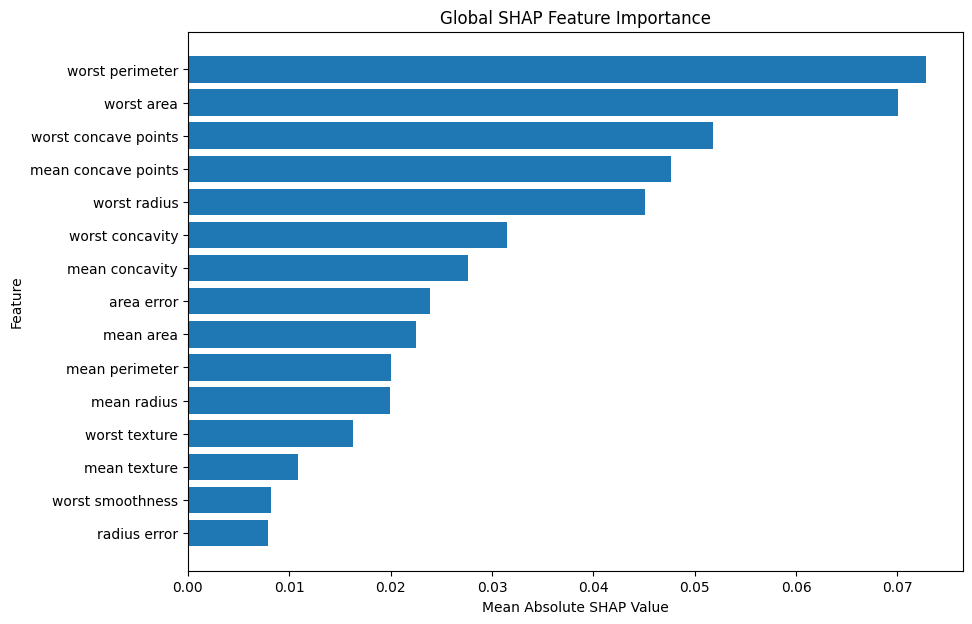

In [44]:
plt.figure(figsize=(10, 7))

top_features = shap_importance.head(15).sort_values(
    "Mean Absolute SHAP"
)

plt.barh(
    top_features["Feature"],
    top_features["Mean Absolute SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Global SHAP Feature Importance")
plt.show()

In [45]:
top5 = shap_importance.head(5)

print("Top 5 SHAP Features:")
display(top5)

Top 5 SHAP Features:


,Feature,Mean Absolute SHAP
22,worst perimeter,0.072819
23,worst area,0.070043
27,worst concave points,0.051765
7,mean concave points,0.047613
20,worst radius,0.045062


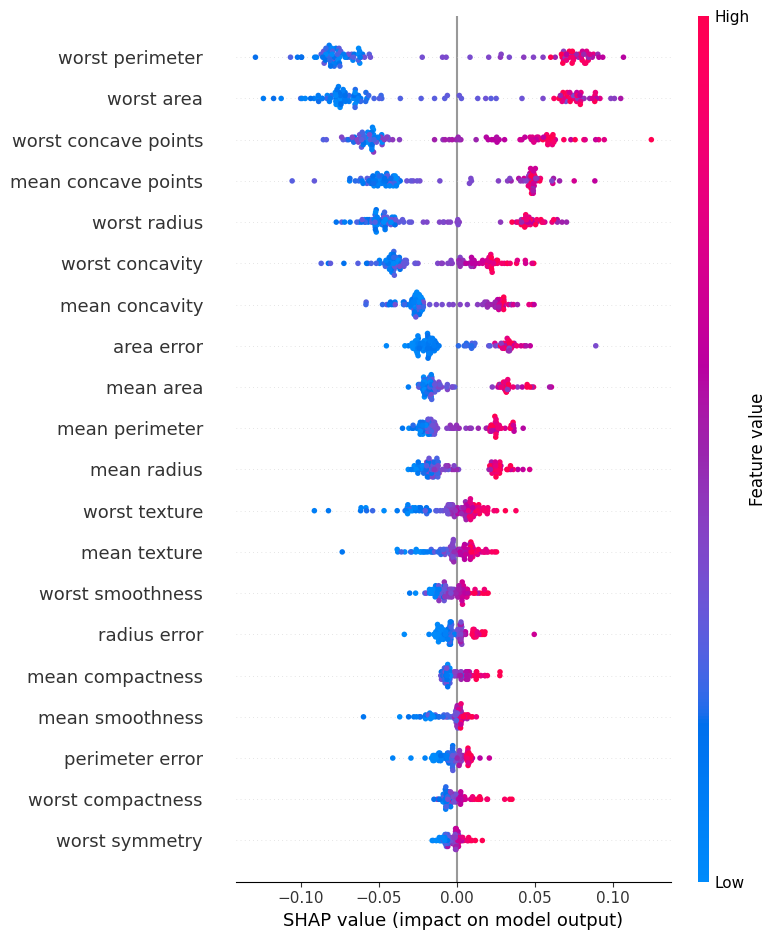

In [46]:
shap.summary_plot(
    shap_malignant,
    X_test,
    show=True
)

In [47]:
top3_features = shap_importance.head(3)["Feature"].tolist()

print("Top 3 features:")
for feature in top3_features:
    print(feature)

Top 3 features:
worst perimeter
worst area
worst concave points


In [48]:
sample_index = 0

print("Actual class:",
      data.target_names[y_test.iloc[sample_index]])

print("Predicted class:",
      data.target_names[y_pred[sample_index]])

print("Prediction probabilities:",
      y_prob[sample_index])

Actual class: malignant
Predicted class: malignant
Prediction probabilities: [1. 0.]


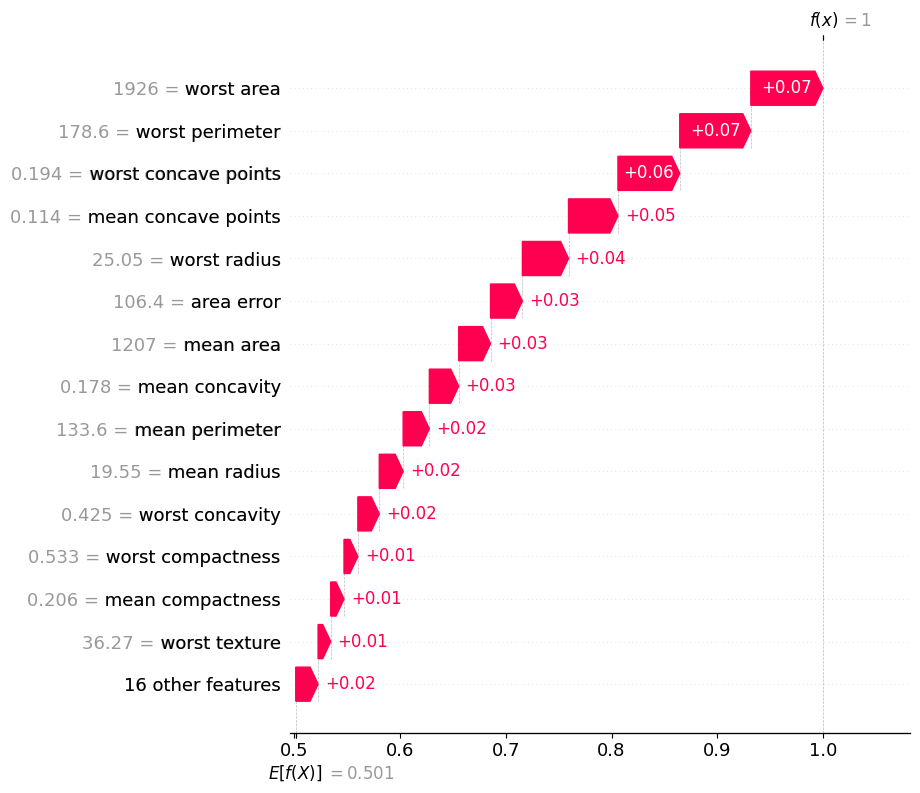

In [49]:
shap.plots.waterfall(
    shap_values[sample_index, :, 0],
    max_display=15
)

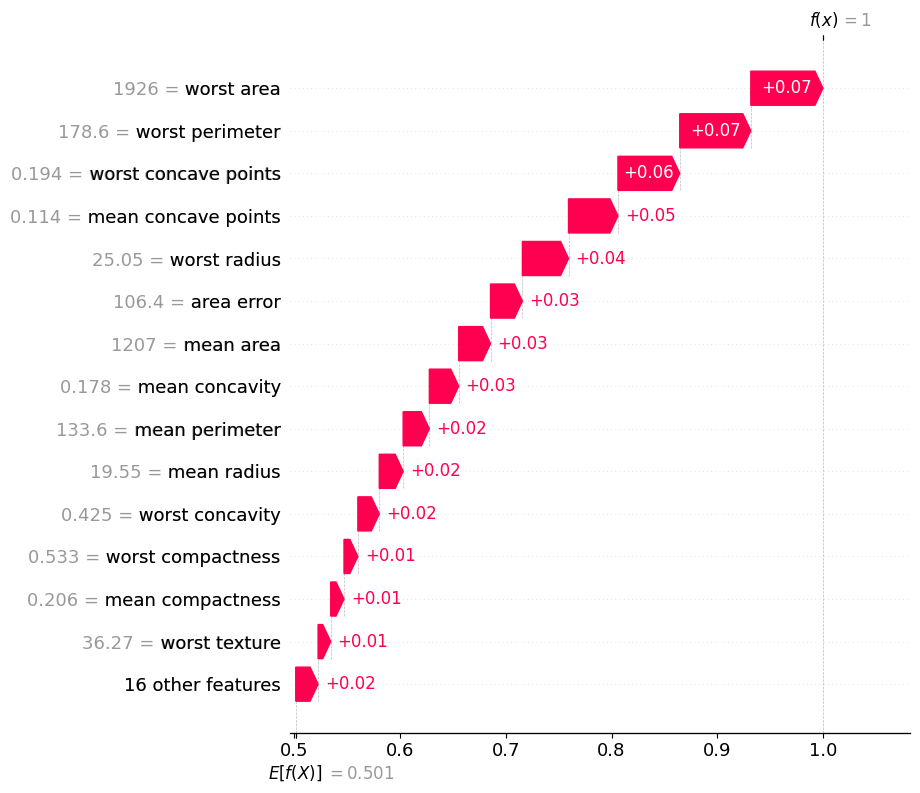

In [50]:
sample_explanation = shap.Explanation(
    values=shap_malignant[sample_index],
    base_values=explainer.expected_value[0],
    data=X_test.iloc[sample_index].values,
    feature_names=X_test.columns.tolist()
)

shap.plots.waterfall(
    sample_explanation,
    max_display=15
)

In [51]:
shap.initjs()

shap.force_plot(
    explainer.expected_value[0],
    shap_malignant[sample_index],
    X_test.iloc[sample_index],
    matplotlib=False
)

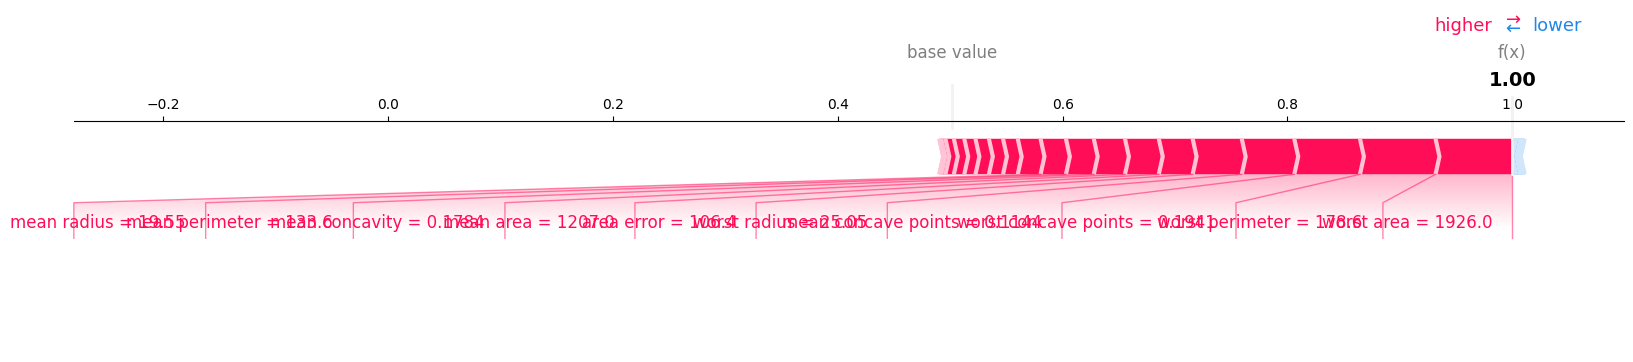

In [52]:
shap.force_plot(
    explainer.expected_value[0],
    shap_malignant[sample_index],
    X_test.iloc[sample_index],
    matplotlib=True
)

In [53]:
top3_features

['worst perimeter', 'worst area', 'worst concave points']

Dependence plot: worst perimeter


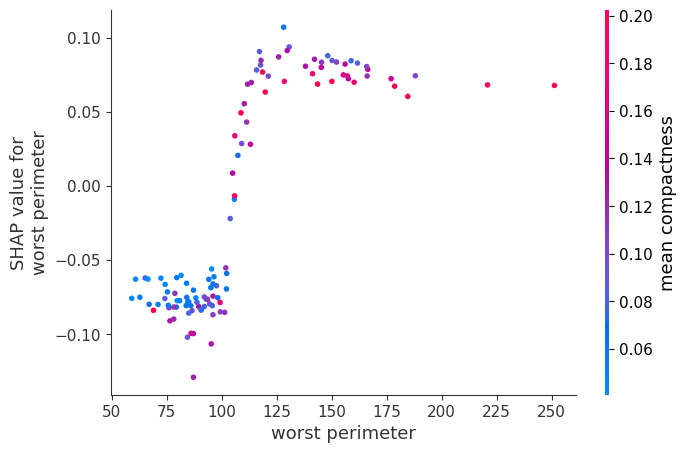

Dependence plot: worst area


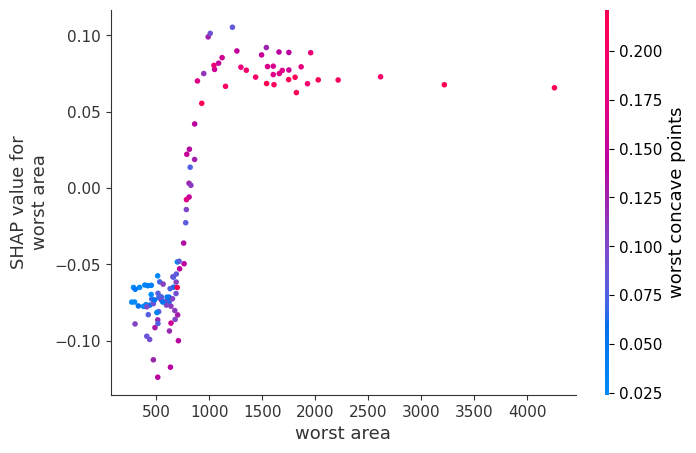

Dependence plot: worst concave points


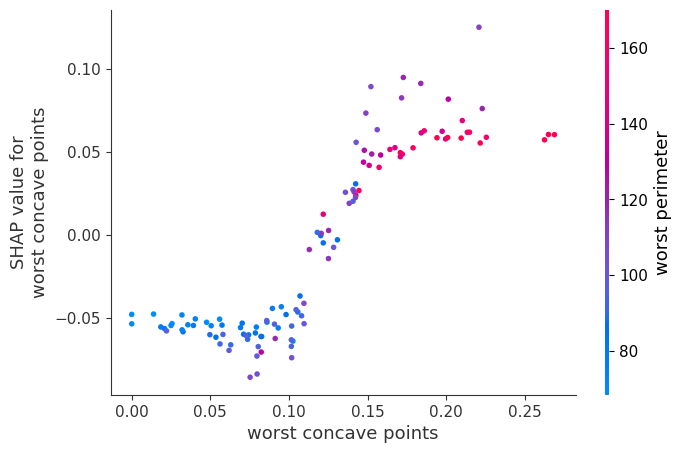

In [54]:
for feature in top3_features:
    print("Dependence plot:", feature)

    shap.dependence_plot(
        feature,
        shap_malignant,
        X_test,
        interaction_index="auto"
    )

In [55]:
sample_indices = [0, 1, 2]

comparison = []

for idx in sample_indices:
    comparison.append({
        "Sample": idx,
        "Actual": data.target_names[y_test.iloc[idx]],
        "Predicted": data.target_names[y_pred[idx]],
        "Probability Malignant": y_prob[idx, 0],
        "Probability Benign": y_prob[idx, 1]
    })

comparison_df = pd.DataFrame(comparison)

display(comparison_df)

,Sample,Actual,Predicted,Probability Malignant,Probability Benign
0,0,malignant,malignant,1.00,0.00
1,1,benign,benign,0.00,1.00
2,2,malignant,malignant,0.91,0.09


In [56]:
for idx in sample_indices:
    sample_shap = shap_malignant[idx]

    temp = pd.DataFrame({
        "Feature": X_test.columns,
        "SHAP": sample_shap
    })

    temp["Absolute SHAP"] = np.abs(temp["SHAP"])

    print("\nSample:", idx)
    print("Actual:", data.target_names[y_test.iloc[idx]])
    print("Predicted:", data.target_names[y_pred[idx]])

    display(
        temp.sort_values(
            "Absolute SHAP",
            ascending=False
        ).head(5)
    )


Sample: 0
Actual: malignant
Predicted: malignant


,Feature,SHAP,Absolute SHAP
23,worst area,0.068249,0.068249
22,worst perimeter,0.067227,0.067227
27,worst concave points,0.058442,0.058442
7,mean concave points,0.046750,0.046750
20,worst radius,0.043669,0.043669



Sample: 1
Actual: benign
Predicted: benign


,Feature,SHAP,Absolute SHAP
22,worst perimeter,-0.066518,0.066518
23,worst area,-0.064042,0.064042
27,worst concave points,-0.050425,0.050425
20,worst radius,-0.041345,0.041345
26,worst concavity,-0.040406,0.040406



Sample: 2
Actual: malignant
Predicted: malignant


,Feature,SHAP,Absolute SHAP
27,worst concave points,0.089180,0.089180
7,mean concave points,0.066021,0.066021
6,mean concavity,0.049677,0.049677
22,worst perimeter,0.033789,0.033789
23,worst area,0.022052,0.022052


In [57]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Random Forest Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Random Forest Importance",
    ascending=False
)

display(rf_importance.head(10))

,Feature,Random Forest Importance
22,worst perimeter,0.143257
23,worst area,0.130836
27,worst concave points,0.106208
7,mean concave points,0.096277
20,worst radius,0.082035
6,mean concavity,0.052928
2,mean perimeter,0.048060
0,mean radius,0.045953
3,mean area,0.042868
26,worst concavity,0.042752


In [58]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Random Forest Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Random Forest Importance",
    ascending=False
)

display(rf_importance.head(10))

,Feature,Random Forest Importance
22,worst perimeter,0.143257
23,worst area,0.130836
27,worst concave points,0.106208
7,mean concave points,0.096277
20,worst radius,0.082035
6,mean concavity,0.052928
2,mean perimeter,0.048060
0,mean radius,0.045953
3,mean area,0.042868
26,worst concavity,0.042752


In [59]:
comparison_importance = shap_importance.merge(
    rf_importance,
    on="Feature"
)

display(comparison_importance.head(10))

,Feature,Mean Absolute SHAP,Random Forest Importance
0,worst perimeter,0.072819,0.143257
1,worst area,0.070043,0.130836
2,worst concave points,0.051765,0.106208
3,mean concave points,0.047613,0.096277
4,worst radius,0.045062,0.082035
5,worst concavity,0.031471,0.042752
6,mean concavity,0.027600,0.052928
7,area error,0.023931,0.041271
8,mean area,0.022528,0.042868
9,mean perimeter,0.020006,0.048060


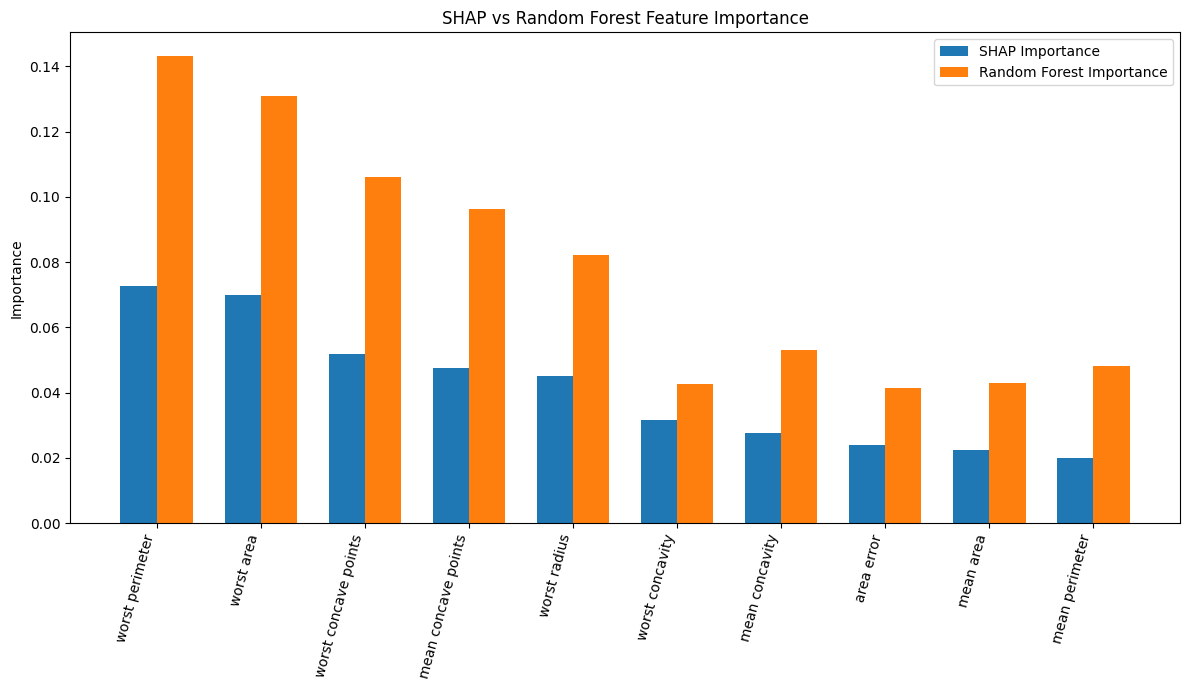

In [60]:
top10_compare = comparison_importance.head(10).copy()

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(top10_compare))
width = 0.35

ax.bar(
    x - width/2,
    top10_compare["Mean Absolute SHAP"],
    width,
    label="SHAP Importance"
)

ax.bar(
    x + width/2,
    top10_compare["Random Forest Importance"],
    width,
    label="Random Forest Importance"
)

ax.set_xticks(x)
ax.set_xticklabels(
    top10_compare["Feature"],
    rotation=75,
    ha="right"
)

ax.set_ylabel("Importance")
ax.set_title("SHAP vs Random Forest Feature Importance")
ax.legend()

plt.tight_layout()
plt.show()

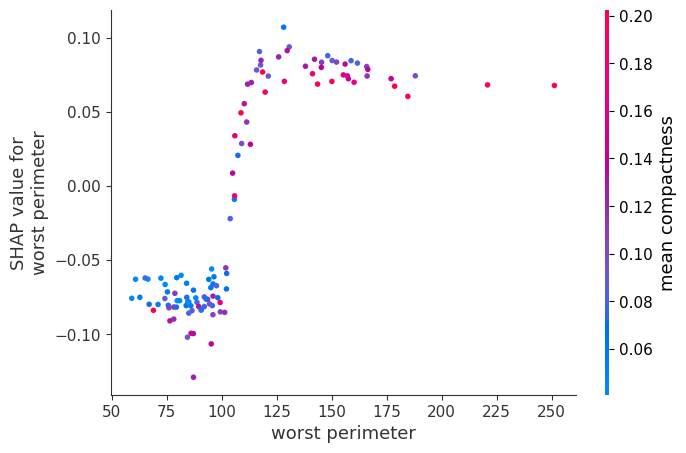

In [61]:
main_feature = top3_features[0]

shap.dependence_plot(
    main_feature,
    shap_malignant,
    X_test,
    interaction_index="auto"
)

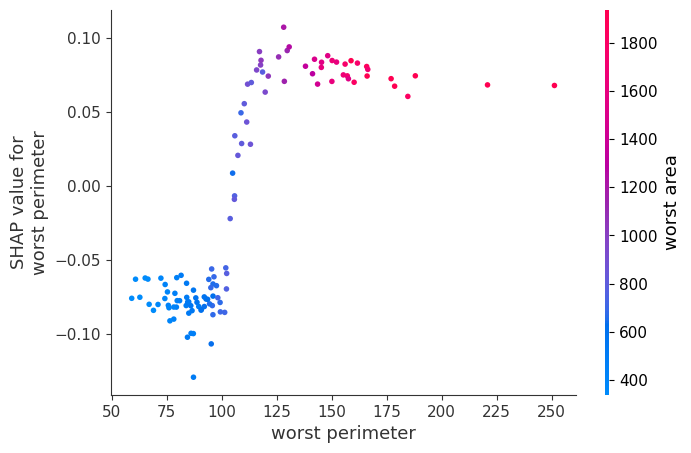

In [62]:
feature1 = top3_features[0]
feature2 = top3_features[1]

shap.dependence_plot(
    feature1,
    shap_malignant,
    X_test,
    interaction_index=feature2
)

In [63]:
print("Five Most Important Features:")
display(shap_importance.head(5))

Five Most Important Features:


,Feature,Mean Absolute SHAP
22,worst perimeter,0.072819
23,worst area,0.070043
27,worst concave points,0.051765
7,mean concave points,0.047613
20,worst radius,0.045062


In [64]:
max_positive_idx = np.unravel_index(
    np.argmax(shap_malignant),
    shap_malignant.shape
)

max_negative_idx = np.unravel_index(
    np.argmin(shap_malignant),
    shap_malignant.shape
)

print(
    "Strongest positive contribution:",
    X_test.columns[max_positive_idx[1]],
    shap_malignant[max_positive_idx]
)

print(
    "Strongest negative contribution:",
    X_test.columns[max_negative_idx[1]],
    shap_malignant[max_negative_idx]
)

Strongest positive contribution: worst concave points 0.12487692722070233
Strongest negative contribution: worst perimeter -0.12905896071526196


In [65]:
max_positive_idx = np.unravel_index(
    np.argmax(shap_malignant),
    shap_malignant.shape
)

max_negative_idx = np.unravel_index(
    np.argmin(shap_malignant),
    shap_malignant.shape
)

print(
    "Strongest positive contribution:",
    X_test.columns[max_positive_idx[1]],
    shap_malignant[max_positive_idx]
)

print(
    "Strongest negative contribution:",
    X_test.columns[max_negative_idx[1]],
    shap_malignant[max_negative_idx]
)

Strongest positive contribution: worst concave points 0.12487692722070233
Strongest negative contribution: worst perimeter -0.12905896071526196


In [66]:
misclassified_indices = np.where(
    y_test.values != y_pred
)[0]

print("Number of misclassified samples:",
      len(misclassified_indices))

print("Misclassified indices:",
      misclassified_indices)

Number of misclassified samples: 6
Misclassified indices: [ 3 16 25 35 53 65]


In [67]:
mis_idx = misclassified_indices[0]

print("Test index:", mis_idx)
print("Actual:", data.target_names[y_test.iloc[mis_idx]])
print("Predicted:", data.target_names[y_pred[mis_idx]])

print("\nProbabilities:")
print("Malignant:", y_prob[mis_idx, 0])
print("Benign:", y_prob[mis_idx, 1])

Test index: 3
Actual: benign
Predicted: malignant

Probabilities:
Malignant: 0.665
Benign: 0.335


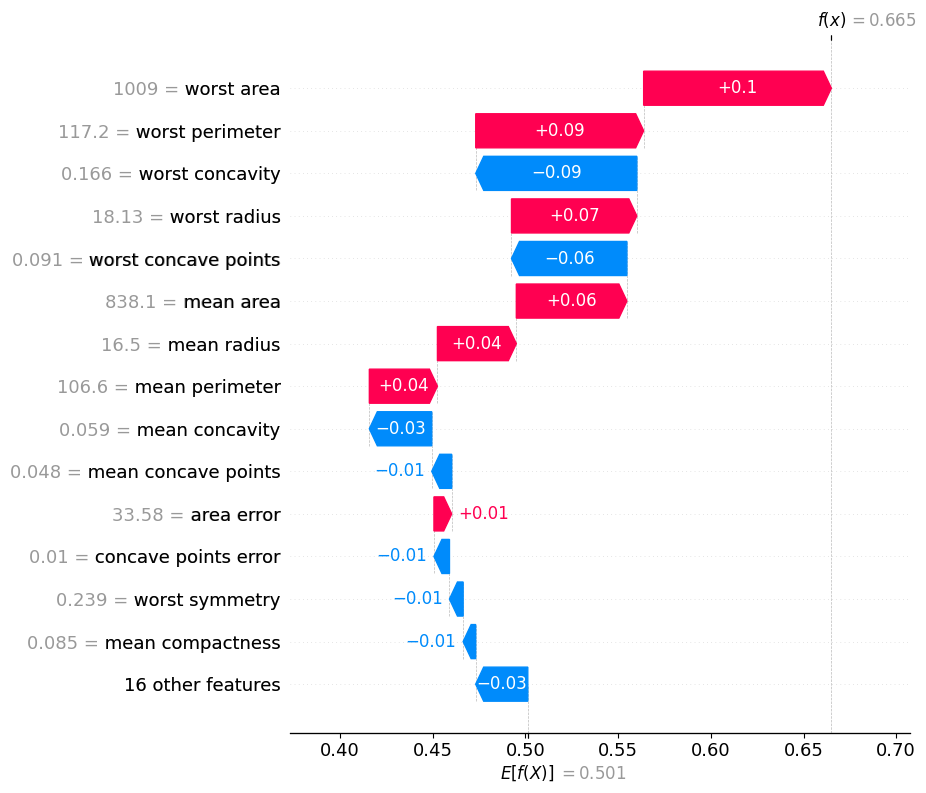

In [68]:
mis_explanation = shap.Explanation(
    values=shap_malignant[mis_idx],
    base_values=explainer.expected_value[0],
    data=X_test.iloc[mis_idx].values,
    feature_names=X_test.columns.tolist()
)

shap.plots.waterfall(
    mis_explanation,
    max_display=15
)

In [69]:
mis_contributions = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP Value": shap_malignant[mis_idx]
})

mis_contributions["Absolute SHAP"] = np.abs(
    mis_contributions["SHAP Value"]
)

display(
    mis_contributions.sort_values(
        "Absolute SHAP",
        ascending=False
    ).head(10)
)

,Feature,SHAP Value,Absolute SHAP
23,worst area,0.101228,0.101228
22,worst perimeter,0.090563,0.090563
26,worst concavity,-0.086882,0.086882
20,worst radius,0.067599,0.067599
27,worst concave points,-0.062234,0.062234
3,mean area,0.059632,0.059632
0,mean radius,0.042548,0.042548
2,mean perimeter,0.036721,0.036721
6,mean concavity,-0.033652,0.033652
7,mean concave points,-0.010763,0.010763


In [70]:
correct_indices = np.where(
    y_test.values == y_pred
)[0]

correct_idx = correct_indices[0]

print("Test index:", correct_idx)
print("Actual:", data.target_names[y_test.iloc[correct_idx]])
print("Predicted:", data.target_names[y_pred[correct_idx]])

Test index: 0
Actual: malignant
Predicted: malignant


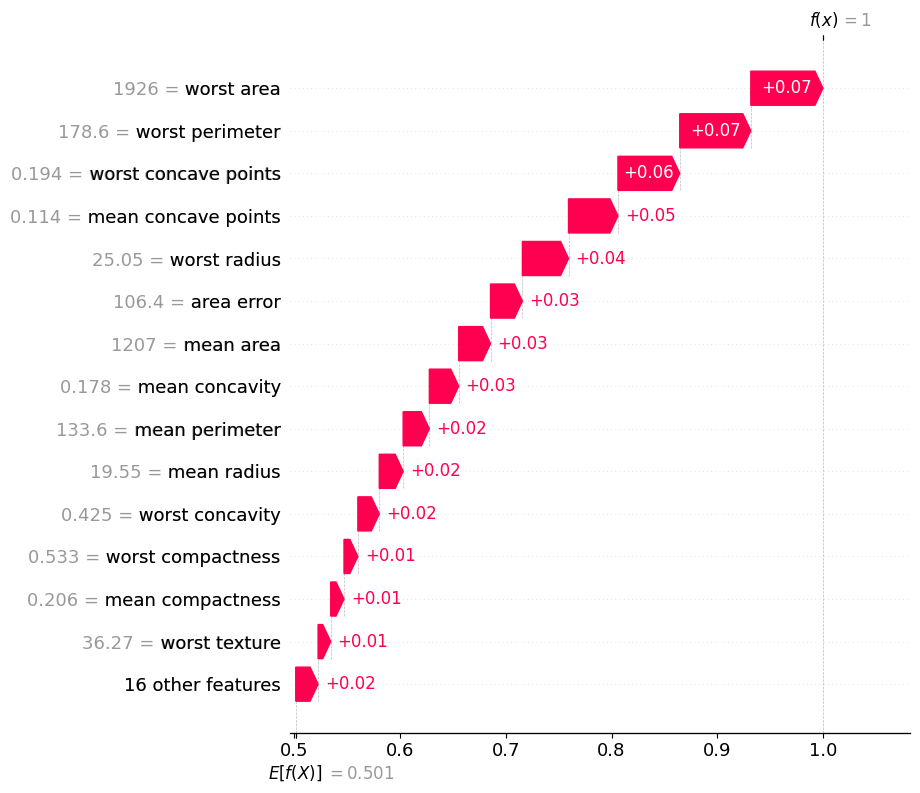

In [71]:
correct_explanation = shap.Explanation(
    values=shap_malignant[correct_idx],
    base_values=explainer.expected_value[0],
    data=X_test.iloc[correct_idx].values,
    feature_names=X_test.columns.tolist()
)

shap.plots.waterfall(
    correct_explanation,
    max_display=15
)

In [72]:
print("MISCLASSIFIED SAMPLE")
print("--------------------")
print("Actual:",
      data.target_names[y_test.iloc[mis_idx]])
print("Predicted:",
      data.target_names[y_pred[mis_idx]])

print("\nCORRECTLY CLASSIFIED SAMPLE")
print("---------------------------")
print("Actual:",
      data.target_names[y_test.iloc[correct_idx]])
print("Predicted:",
      data.target_names[y_pred[correct_idx]])

MISCLASSIFIED SAMPLE
--------------------
Actual: benign
Predicted: malignant

CORRECTLY CLASSIFIED SAMPLE
---------------------------
Actual: malignant
Predicted: malignant
